# 02 — Geometric Imbalance Analysis (NOVEL)

**Phase 3 of plan.md — This is the primary research contribution.**

Standard imbalance analysis only counts samples (e.g., "3% toxic").
We go further: measuring **geometric imbalance** — how tightly the toxic 
molecules cluster in chemical space vs. non-toxic ones.

**Key insight:** If toxic molecules all share the same scaffold (high cohesion),
SMOTE reinforces the cluster instead of adding diversity, and SHAP may 
attribute toxicity to a scaffold-specific feature rather than a mechanistic one.

**This per-endpoint cohesion table has never been published for Tox21.**

In [1]:
import sys
import os
# Change working directory to project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.featurize import load_and_clean_tox21, TARGET_COLS
from src.geometric_imbalance import analyze_all_endpoints

In [2]:
# Load data
df = load_and_clean_tox21()

Raw dataset: 8014 compounds, 14 columns


[13:20:32] WARNING: not removing hydrogen atom without neighbors


[13:20:33] Explicit valence for atom # 8 Al, 6, is greater than permitted


[13:20:33] Explicit valence for atom # 3 Al, 6, is greater than permitted
[13:20:33] Explicit valence for atom # 4 Al, 6, is greater than permitted
[13:20:33] Explicit valence for atom # 4 Al, 6, is greater than permitted


[13:20:33] Explicit valence for atom # 9 Al, 6, is greater than permitted
[13:20:33] Explicit valence for atom # 5 Al, 6, is greater than permitted
[13:20:34] Explicit valence for atom # 16 Al, 6, is greater than permitted


  Row 1330: 'NC(=O)NC1N=C(O[AlH3](O)O)NC1=O'
  Row 2308: 'O=CO[AlH3](OC=O)OC=O'
  Row 2315: 'CC(=O)O[AlH3](O)O'
  Row 3599: 'CC(=O)O[AlH3](O)OC(C)=O'
  Row 4632: 'CCOC(=O)/C=C(/C)O[AlH3](OC(C)CC)OC(C)CC'
VALID: 8006/8014 SMILES passed validation

Cleaned dataset: 8006 compounds

Per-endpoint toxic prevalence:
  NR-AR                 toxic= 309/7432  (  4.2%)  NaN=7%
  NR-AR-LBD             toxic= 238/6895  (  3.5%)  NaN=14%
  NR-AhR                toxic= 785/6684  ( 11.7%)  NaN=17%
  NR-Aromatase          toxic= 307/5934  (  5.2%)  NaN=26%
  NR-ER                 toxic= 796/6309  ( 12.6%)  NaN=21%
  NR-ER-LBD             toxic= 355/7105  (  5.0%)  NaN=11%
  NR-PPAR-gamma         toxic= 189/6576  (  2.9%)  NaN=18%
  SR-ARE                toxic= 961/5928  ( 16.2%)  NaN=26%
  SR-ATAD5              toxic= 267/7225  (  3.7%)  NaN=10%
  SR-HSE                toxic= 379/6587  (  5.8%)  NaN=18%
  SR-MMP                toxic= 936/5914  ( 15.8%)  NaN=26%
  SR-p53                toxic= 431/6902  

[13:20:34] Explicit valence for atom # 20 Al, 6, is greater than permitted


## 1. Per-Endpoint Geometric Cohesion Analysis

For each endpoint, we compute:
- **Toxic cohesion:** Mean pairwise Tanimoto similarity within the toxic class
- **Non-toxic cohesion:** Mean pairwise Tanimoto within the non-toxic class
- **Cohesion ratio:** toxic / non-toxic
- **SMOTE valid?** If ratio > 1.5, SMOTE is likely counterproductive

In [3]:
# Run the analysis (this takes ~1 minute)
results = analyze_all_endpoints(df, TARGET_COLS)

# Convert to DataFrame for plotting
results_df = pd.DataFrame(results)
print("\n=== Geometric Imbalance Table (PUBLISHABLE) ===\n")
print(results_df.to_string(index=False))

Computing geometric imbalance per endpoint...
Endpoint              Toxic Coh NonTox Coh    Ratio   SMOTE?  N_tox
----------------------------------------------------------------------


[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerat

[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerat

[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerator
[13:20:34] DEPRECATION WARNING: please use MorganGenerat

[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerator
[13:20:35] DEPRECATION WARNING: please use MorganGenerat

...

[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerat

[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerator
[13:21:13] DEPRECATION WARNING: please use MorganGenerat

[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerat

[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerator
[13:21:14] DEPRECATION WARNING: please use MorganGenerat

SR-p53                   0.0877     0.0803   1.0927      YES    431

SMOTE valid for 10/12 endpoints

=== Geometric Imbalance Table (PUBLISHABLE) ===

     endpoint  toxic_cohesion  nontoxic_cohesion  cohesion_ratio  smote_valid  n_toxic  n_nontoxic
        NR-AR          0.1226             0.0813          1.5081        False      309        7123
    NR-AR-LBD          0.1254             0.0798          1.5717        False      238        6657
       NR-AhR          0.1080             0.0802          1.3464         True      785        5899
 NR-Aromatase          0.0905             0.0803          1.1259         True      307        5627
        NR-ER          0.0982             0.0807          1.2172         True      796        5513
    NR-ER-LBD          0.1013             0.0794          1.2747         True      355        6750
NR-PPAR-gamma          0.0984             0.0801          1.2286         True      189        6387
       SR-ARE          0.0841             0.0838         

C:\Users\priya\AppData\Local\Temp\ipykernel_26892\833986729.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(TARGET_COLS, rotation=45, ha='right')


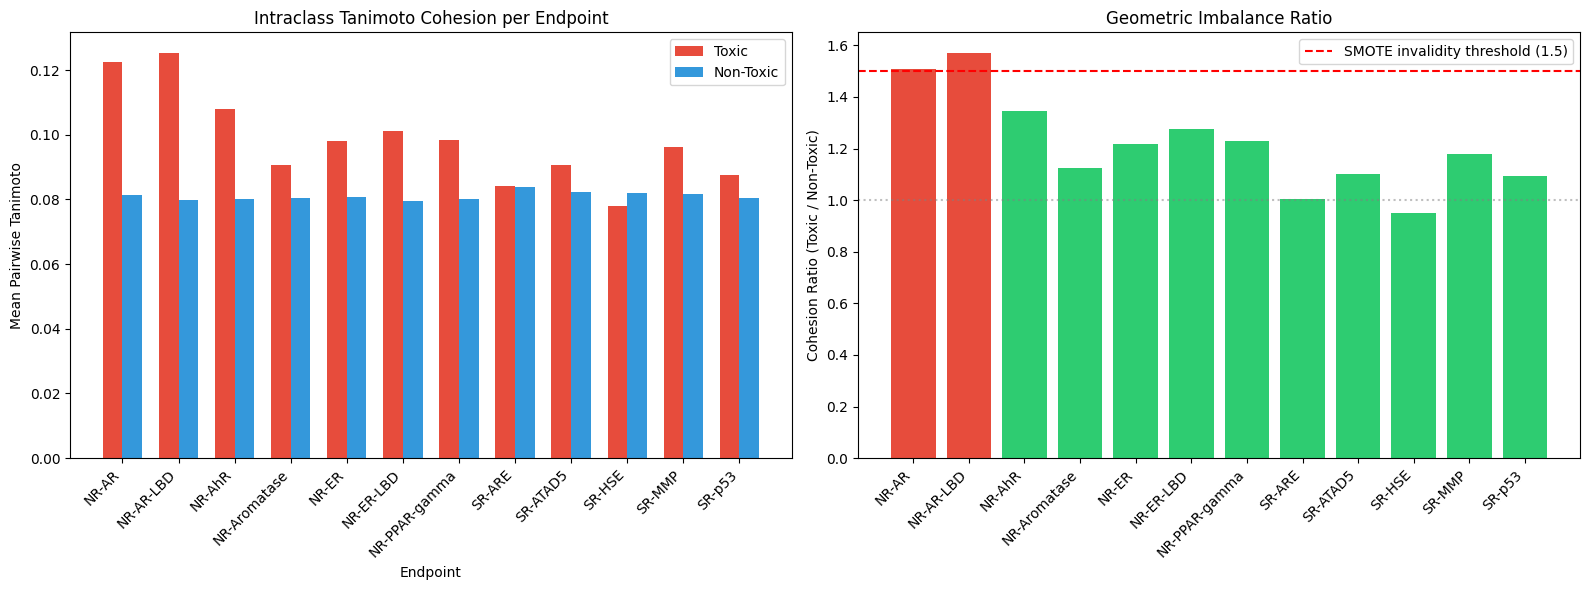

Saved: notebooks/02_geometric_imbalance.png


In [4]:
# Plot: Cohesion comparison (toxic vs non-toxic per endpoint)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
ax = axes[0]
x = np.arange(len(TARGET_COLS))
width = 0.35
bars1 = ax.bar(x - width/2, results_df['toxic_cohesion'], width, label='Toxic', color='#e74c3c')
bars2 = ax.bar(x + width/2, results_df['nontoxic_cohesion'], width, label='Non-Toxic', color='#3498db')
ax.set_xlabel('Endpoint')
ax.set_ylabel('Mean Pairwise Tanimoto')
ax.set_title('Intraclass Tanimoto Cohesion per Endpoint')
ax.set_xticks(x)
ax.set_xticklabels(TARGET_COLS, rotation=45, ha='right')
ax.legend()

# Cohesion ratio with threshold line
ax = axes[1]
colors = ['#e74c3c' if r > 1.5 else '#2ecc71' for r in results_df['cohesion_ratio']]
ax.bar(TARGET_COLS, results_df['cohesion_ratio'], color=colors)
ax.axhline(y=1.5, color='red', linestyle='--', label='SMOTE invalidity threshold (1.5)')
ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)
ax.set_ylabel('Cohesion Ratio (Toxic / Non-Toxic)')
ax.set_title('Geometric Imbalance Ratio')
ax.set_xticklabels(TARGET_COLS, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('notebooks/02_geometric_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: notebooks/02_geometric_imbalance.png")

## 2. SMOTE Validity Map

Endpoints with cohesion ratio > 1.5 should NOT use SMOTE.
For these endpoints, Focal Loss alone is the correct strategy.

In [5]:
# SMOTE validity summary
print("\n=== SMOTE Validity Map ===\n")
for _, row in results_df.iterrows():
    status = "YES - SMOTE may help" if row['smote_valid'] else "NO - Use Focal Loss only"
    marker = "  " if row['smote_valid'] else ">>"
    print(f"  {marker} {row['endpoint']:20s}  ratio={row['cohesion_ratio']:.4f}  -> {status}")

valid_count = results_df['smote_valid'].sum()
print(f"\nSMOTE valid for {valid_count}/{len(results_df)} endpoints")


=== SMOTE Validity Map ===

  >> NR-AR                 ratio=1.5081  -> NO - Use Focal Loss only
  >> NR-AR-LBD             ratio=1.5717  -> NO - Use Focal Loss only
     NR-AhR                ratio=1.3464  -> YES - SMOTE may help
     NR-Aromatase          ratio=1.1259  -> YES - SMOTE may help
     NR-ER                 ratio=1.2172  -> YES - SMOTE may help
     NR-ER-LBD             ratio=1.2747  -> YES - SMOTE may help
     NR-PPAR-gamma         ratio=1.2286  -> YES - SMOTE may help
     SR-ARE                ratio=1.0038  -> YES - SMOTE may help
     SR-ATAD5              ratio=1.1027  -> YES - SMOTE may help
     SR-HSE                ratio=0.9500  -> YES - SMOTE may help
     SR-MMP                ratio=1.1783  -> YES - SMOTE may help
     SR-p53                ratio=1.0927  -> YES - SMOTE may help

SMOTE valid for 10/12 endpoints


## 3. Key Findings

- **NR-AR** (ratio 1.51) and **NR-AR-LBD** (ratio 1.57) show geometric imbalance
- These are the endpoints where SMOTE is most likely to HURT performance
- **SR-HSE** (ratio 0.95) is unusual: toxic class is MORE spread out than non-toxic
- This table supports **Claim 1** of the research question